# 1. Importation des librairies

In [2]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

# 2. Chargement et traitement des données

In [3]:
data = pd.read_csv ('my_courses.csv', decimal=".", index_col=0)

In [4]:
data.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3,22,4470531
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4,8,4525306
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0,89,4525296
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2,57,4452741
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3,29,3595541


Dans cet échantillon, chaque individu est un cours que suivi. Voici le détail des variables :

- titreCours : le titre du cours ;

- idCours : l'identifiant du cours ;

- inscription : nombre de jours écoulés depuis votre inscription au cours ;

- progression : votre progression sur le cours (en pourcentage) ;

- moyenneDeClasse : moyenne de la classe aux évaluations (en pourcentage) ;

- duree : durée estimée du cours (en heures) ;

- difficulte : difficulté estimée du cours (1 : facile... 3 : difficile) ;

- nbChapitres : nombre de chapitres ;

- nbEvaluations : nombre d'évaluations dans le cours (comprend les quiz et les activités) ;

- ratioQuizEvaluation : proportion de quiz par rapport au nombre total d'évaluations (nombre d'évaluations : nombre de quiz + nombre d'activités). 

## 2.1. Visualisation rapide des données

In [5]:
data.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3,22,4470531
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4,8,4525306
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0,89,4525296
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2,57,4452741
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3,29,3595541


In [6]:
data.tail()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Apprenez_à_programmer_en_Python,349,4,84.0,40.0,3,38,0.500000,4,151,235344
Réalisez_des_calculs_distribués_sur_des_données_massives,377,34,85.0,20.0,2,15,0.500000,4,91,4297166
Évaluez_et_améliorez_les_performances_d'un_modèle_de_machine_learning,412,58,90.0,10.0,2,8,0.333333,3,18,4297211
Créez_un_cours_sur_OpenClassrooms,439,100,NaN,1.0,1,10,NaN,0,148,2067781
Développez_votre_site_web_avec_le_framework_Symfony,713,2,90.0,30.0,2,27,0.714286,7,64,3619856


In [7]:
#dimension du dataframe
data.shape

(19, 10)

In [8]:
# Indications globales sur les données grâce à la méthode info
data.info()

<class 'pandas.DataFrame'>
Index: 19 entries, Classez_et_segmentez_des_données_visuelles to Développez_votre_site_web_avec_le_framework_Symfony
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   inscription          19 non-null     int64  
 1   progression          19 non-null     int64  
 2   moyenneDeClasse      15 non-null     float64
 3   duree                18 non-null     float64
 4   difficulte           19 non-null     int64  
 5   nbChapitres          19 non-null     int64  
 6   ratioQuizEvaluation  16 non-null     float64
 7   nbEvaluations        19 non-null     int64  
 8   derniereMiseAJour    19 non-null     int64  
 9   idCours              19 non-null     int64  
dtypes: float64(3), int64(7)
memory usage: 1.6+ KB


In [9]:
# Vérification des valeurs manquantes par colonne
data.isna().mean()

inscription            0.000000
progression            0.000000
moyenneDeClasse        0.210526
duree                  0.052632
difficulte             0.000000
nbChapitres            0.000000
ratioQuizEvaluation    0.157895
nbEvaluations          0.000000
derniereMiseAJour      0.000000
idCours                0.000000
dtype: float64

Nous observons des données manquantes pour les variables moyenneDeClasse, duree et ratioQuizEvaluation

In [10]:
# vérification des lignes en double
data.duplicated().sum()

np.int64(0)

In [11]:
# Vérification des valeurs différentes par colonne
data.nunique()

inscription            17
progression            13
moyenneDeClasse        11
duree                  10
difficulte              3
nbChapitres            18
ratioQuizEvaluation     7
nbEvaluations           5
derniereMiseAJour      17
idCours                19
dtype: int64

In [12]:
# Dispersion globale des données
data.describe()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
count,19.000000,19.000000,15.000000,18.000000,19.000000,19.000000,16.000000,19.000000,19.000000,1.900000e+01
mean,235.473684,44.052632,89.400000,15.000000,1.894737,15.210526,0.617560,2.947368,78.578947,3.967983e+06
std,167.684349,36.326412,3.996427,10.318459,0.657836,9.223032,0.246053,1.715086,63.453671,1.075638e+06
min,29.000000,2.000000,84.000000,1.000000,1.000000,1.000000,0.000000,0.000000,8.000000,2.353440e+05
25%,134.000000,4.000000,85.500000,8.500000,1.500000,8.500000,0.500000,2.000000,22.000000,4.056556e+06
50%,195.000000,44.000000,90.000000,13.500000,2.000000,13.000000,0.666667,3.000000,61.000000,4.421146e+06
75%,310.500000,70.000000,92.000000,20.000000,2.000000,20.500000,0.750000,4.000000,146.500000,4.469006e+06
max,713.000000,100.000000,96.000000,40.000000,3.000000,38.000000,1.000000,7.000000,186.000000,4.525306e+06


## 2.2. Sélection des données

In [13]:
#Sélection des colonnes
cols = ['inscription', 'progression','moyenneDeClasse','duree','difficulte','nbChapitres','ratioQuizEvaluation','nbEvaluations']

# Création du nouveau dataframe
data = data [cols]
data.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations
titreCours,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3


Nous avons supprimé les colonnes 'derniereMiseAJour' et 'idCours' car elles sont des variables qualitatives. L'analyse développée dans ce projet est essentiellement quantitative.

In [14]:
data.shape

(19, 8)

## 2.3. Nettoyage des données

In [15]:
#Traitement des valeurs manquantes, elles sont remplacées par les moyennes

data = data.fillna (data.mean())
data.isna().mean()

inscription            0.0
progression            0.0
moyenneDeClasse        0.0
duree                  0.0
difficulte             0.0
nbChapitres            0.0
ratioQuizEvaluation    0.0
nbEvaluations          0.0
dtype: float64

Par souci de simplicité, nous avons fait le choix ici de remplacer les données manquantes dans les variables moyenneDeClasse, duree et ratioQuizEvaluation par les moyennes de valeurs existantes pour chaque variable

## 2.4. Séparation des données

In [16]:
# La matrice de données
X = data.values

# Un tableau contenant les noms des cours
names = data.index

#un tableau contenant les noms des colonnes 
features = data.columns

In [17]:
X

array([[2.90000000e+01, 3.40000000e+01, 8.94000000e+01, 1.50000000e+01,
        3.00000000e+00, 1.10000000e+01, 6.66666667e-01, 3.00000000e+00],
       [5.50000000e+01, 4.00000000e+00, 8.60000000e+01, 1.20000000e+01,
        2.00000000e+00, 2.10000000e+01, 7.50000000e-01, 4.00000000e+00],
       [6.00000000e+01, 1.00000000e+02, 8.94000000e+01, 1.50000000e+01,
        1.00000000e+00, 1.00000000e+00, 6.17559524e-01, 0.00000000e+00],
       [6.40000000e+01, 6.40000000e+01, 9.60000000e+01, 1.00000000e+01,
        2.00000000e+00, 8.00000000e+00, 0.00000000e+00, 2.00000000e+00],
       [7.60000000e+01, 1.00000000e+02, 9.10000000e+01, 6.00000000e+00,
        1.00000000e+00, 1.20000000e+01, 1.00000000e+00, 3.00000000e+00],
       [1.92000000e+02, 1.40000000e+01, 9.20000000e+01, 2.00000000e+01,
        2.00000000e+00, 2.50000000e+01, 5.00000000e-01, 4.00000000e+00],
       [1.92000000e+02, 8.00000000e+01, 8.94000000e+01, 2.00000000e+00,
        1.00000000e+00, 3.00000000e+00, 6.17559524e-01, 0.

In [18]:
names

Index(['Classez_et_segmentez_des_données_visuelles',
       'Initiez-vous_à_la_statistique_inférentielle',
       'Maîtrisez_les_bases_des_probabilités',
       'Découvrez_les_librairies_Python_pour_la_Data_Science',
       'Devenez_mentor_sur_OpenClassrooms',
       'Initiez-vous_à_l'algèbre_relationnelle_avec_le_langage_SQL',
       'Maintenez-vous_à_jour_en_développement',
       'Entraînez_un_modèle_prédictif_linéaire',
       'Explorez_vos_données_avec_des_algorithmes_non_supervisés',
       'Décrivez_et_nettoyez_votre_jeu_de_données', 'Créez_votre_Data_Lake',
       'Développez_une_application_iPhone_avec_le_modèle_MVC',
       'Animez_un_atelier_de_créativité',
       'Faites_une_base_de_données_avec_UML',
       'Apprenez_à_programmer_en_Python',
       'Réalisez_des_calculs_distribués_sur_des_données_massives',
       'Évaluez_et_améliorez_les_performances_d'un_modèle_de_machine_learning',
       'Créez_un_cours_sur_OpenClassrooms',
       'Développez_votre_site_web_avec_le_fr

In [19]:
features

Index(['inscription', 'progression', 'moyenneDeClasse', 'duree', 'difficulte',
       'nbChapitres', 'ratioQuizEvaluation', 'nbEvaluations'],
      dtype='str')

# 3. Analyse en Composantes Principales

## 3.1. Scaling

In [20]:
#On instancie notre fonction
scaler = StandardScaler ()

#notre modèle s'imprègne de nos données pour mémoriseer une moyenne et un écart-type
scaler.fit (X)

# On centre-réduit nos données grâce à la moyenne et la std conservées en mémoire
X_scaled = scaler.transform (X)
print (X_scaled)

[[-1.26506467e+00 -2.84313717e-01  4.14248649e-15  0.00000000e+00
   1.72618937e+00 -4.69032782e-01  2.24619768e-01  3.15283331e-02]
 [-1.10576261e+00 -1.13278921e+00 -9.91105344e-01 -3.07368082e-01
   1.64398987e-01  6.44920075e-01  6.05792707e-01  6.30566661e-01]
 [-1.07512761e+00  1.58233236e+00  4.14248649e-15  0.00000000e+00
  -1.39739139e+00 -1.58298564e+00  0.00000000e+00 -1.76558665e+00]
 [-1.05061960e+00  5.64161774e-01  1.92391037e+00 -5.12280137e-01
   1.64398987e-01 -8.03218639e-01 -2.82476374e+00 -5.67509995e-01]
 [-9.77095574e-01  1.58233236e+00  4.66402515e-01 -9.22104247e-01
  -1.39739139e+00 -3.57637496e-01  1.74931152e+00  3.15283331e-02]
 [-2.66363348e-01 -8.49964045e-01  7.57904087e-01  5.12280137e-01
   1.64398987e-01  1.09050122e+00 -5.37726110e-01  6.30566661e-01]
 [-2.66363348e-01  1.01668204e+00  4.14248649e-15 -1.33192836e+00
  -1.39739139e+00 -1.36019507e+00  0.00000000e+00 -1.76558665e+00]
 [-2.60236346e-01  5.92444290e-01 -1.57410849e+00 -5.12280137e-01
   

In [21]:
#On vérifie que la moyenne et notre écart-type sont respectivement égaux à 0 et 1
idx = ['mean', 'std']
pd.DataFrame (X_scaled).describe().round (2).loc [idx, : ]

,0,1,2,3,4,5,6,7
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.03,1.03,1.03,1.03,1.03,1.03,1.03,1.03


## 3.2. Décomposition en facteurs principaux

In [100]:
#Choix du nombre de composantes (6)
nb_components = 6

#On instancie notre ACP
pca = PCA (n_components= nb_components)

#On entraine notre modèle sur nos données standardisées
pca.fit (X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",6
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## 3.3. Variance expliquée et digramme des eboulis

In [144]:
#Variance expliquée par chaque facteur
pca.explained_variance_ratio_

#Enregistrons cette variance expliquée dans une variable
scree = (pca.explained_variance_ratio_ * 100).round(2)

#somme cumulée des variances expliquées
scree_cum = np.cumsum (scree)
print (scree_cum)

[47.16 62.81 76.49 88.4  92.55 95.59]


Tracé des eboulis des valeurs propres

[1 2 3 4 5 6]


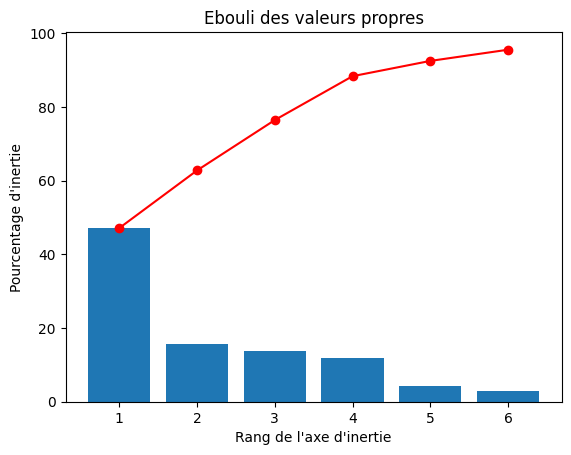

In [145]:
# Définissons une variable avec la liste de nos composantes

x_list = np.array (range (1, nb_components+1))
print (x_list)
# Représentation graphique
#plt.figure (figsize = (10,6))
plt.bar (x_list, scree)
plt.plot (x_list, scree_cum, marker = 'o', c = 'red')
plt.title ('Ebouli des valeurs propres')
plt.xlabel ('Rang de l\'axe d\'inertie')
plt.ylabel ('Pourcentage d\'inertie')
plt.show()

On observe la variance expliquée par chaque nouvelle composante et en rouge variance cumulée.

Le nombre de composantes a initialmeent été fixée à 8 (min (n_samples, n_features)) avant d'être modifié et fixé à 6 car la grande partie (95,59%) de la variance totale est expliquée avec 6 composantes.

Nous aurions également pu nous limiter à 4 composantes (88,4% de variances totale) mais plus de composantes permet de capter plus de variance, d'où le compromis

## Petit supplément

Nous pouvons également obtenir ces composantes grâce à la fonction numpy.linealg.svd

La fonction prend en entrée nos données standardisées et renvoie trois valeurs U, S, Vt

U qui représente la matrice orthogonale, 

S qui représente les valeurs propres et contient l'importance de chaque composante principale

Vt qui contient les vecteurs directions pour les projections. 


Les composantes principales sont les coordonnées des points dans le nouvel espace càd les combinaisons linéaires des variables d'origine dans le nouvel espace

In [26]:
U, S, Vt  = np.linalg.svd (X_scaled)

var_explained = (S**2) / (X_scaled.shape [0]-1)
ratio_var_explained = var_explained / np.sum (var_explained)

print (f'Variance expliquée par chaque composante : {var_explained}')
print (f'Ratio de variance expliquée par chaque composante : {ratio_var_explained}')
print (f'Composantes principales : {Vt}')

Variance expliquée par chaque composante : [3.98235273 1.32164346 1.15493328 1.00562514 0.35027821 0.25694061
 0.21336225 0.15930878]
Ratio de variance expliquée par chaque composante : [0.4715944  0.15651041 0.13676841 0.11908719 0.04148031 0.03042718
 0.02526658 0.01886551]
Composantes principales : [[ 0.23229081 -0.45303568 -0.08449592  0.44865413  0.33114918  0.4643896
   0.08103545  0.4477559 ]
 [-0.1385512   0.09570881 -0.50590131  0.11946397  0.56702258 -0.14819996
  -0.55994188 -0.21076734]
 [-0.2329107  -0.18131195  0.74959103  0.02578145  0.09797129  0.00162489
  -0.57772613  0.08341881]
 [-0.84456256 -0.17345083  0.00374152  0.00379675  0.2511345   0.03195603
   0.43707483 -0.0384231 ]
 [ 0.1019438  -0.10374663 -0.04280049 -0.7043421   0.33049795 -0.25476797
   0.03959608  0.552459  ]
 [-0.24178329 -0.28083669 -0.34571373 -0.38205031 -0.44706348  0.52232025
  -0.35266466  0.01160229]
 [ 0.20531947 -0.7814152  -0.01350894 -0.09142001 -0.00138866 -0.34278705
   0.07256014 -0.4

In [27]:
#Pour obtenir les nouvelles coordonnées des individus
X_projected = X_scaled @ Vt.T
X_projected

array([[ 0.22107277,  1.06394473,  0.3874128 ,  1.63322222,  0.61683984,
        -0.70983399,  0.12245389,  0.18624383],
       [ 0.88754323,  0.03499815, -0.56814276,  1.42793746,  0.52608729,
         1.10258485,  0.22928086, -0.30733529],
       [-2.95501419,  0.11477732, -0.3232466 ,  0.29987584, -1.30771945,
        -0.40701673, -0.09220914, -0.64150265],
       [-1.69361161,  1.07862307,  3.17074995, -0.40249607, -0.05356553,
         0.12275527, -0.30186665, -0.05494682],
       [-1.86989322, -1.7847995 , -0.87896007,  0.9500123 ,  0.08170767,
        -0.19571633, -1.12226331, -0.08019407],
       [ 1.28861015, -0.26687152,  1.17861081,  0.19404767, -0.22865319,
         0.53841576, -0.15365085,  0.09447008],
       [-3.00499944, -0.24355067, -0.44303432, -0.28300115, -0.28521331,
         0.18152462,  0.56124885,  0.06122736],
       [-0.99019557,  1.44435679, -0.96165067, -0.08485137,  0.23596961,
         0.38465086,  0.01333147, -0.27089475],
       [ 0.14098928,  1.65156184

## 3.4. Composantes principales

In [28]:
pca.explained_variance_

array([3.98235273, 1.32164346, 1.15493328, 1.00562514, 0.35027821,
       0.25694061])

In [106]:
# Calcul des composantes principales
pcs = pca.components_

# Transformation en dataframe
pcs = pd.DataFrame (pcs)

pcs.columns = features
pcs.index = [f'F{i}' for i in x_list]
print (pcs.round (2))

    inscription  progression  moyenneDeClasse  duree  difficulte  nbChapitres  \
F1         0.23        -0.45            -0.08   0.45        0.33         0.46   
F2        -0.14         0.10            -0.51   0.12        0.57        -0.15   
F3        -0.23        -0.18             0.75   0.03        0.10         0.00   
F4         0.84         0.17            -0.00  -0.00       -0.25        -0.03   
F5        -0.10         0.10             0.04   0.70       -0.33         0.25   
F6        -0.24        -0.28            -0.35  -0.38       -0.45         0.52   

    ratioQuizEvaluation  nbEvaluations  
F1                 0.08           0.45  
F2                -0.56          -0.21  
F3                -0.58           0.08  
F4                -0.44           0.04  
F5                -0.04          -0.55  
F6                -0.35           0.01  


De ce résultat, on peut conclure que 


`F1 = (0.23 * inscription) + (-0.45 * progression) + ... + (0.45 * nbEvaluations)`

et F2 ?

`F2 = (0.14 * inscription) + (-0.10 * progression) + ... + (0.21 * nbEvaluations)`

etc.

In [30]:
# Dans certains cas le dataframe sera aficher comme suit
pcs.T

,F1,F2,F3,F4,F5,F6
inscription,0.232291,-0.138551,-0.232911,0.844563,-0.101944,-0.241783
progression,-0.453036,0.095709,-0.181312,0.173451,0.103747,-0.280837
moyenneDeClasse,-0.084496,-0.505901,0.749591,-0.003742,0.042800,-0.345714
duree,0.448654,0.119464,0.025781,-0.003797,0.704342,-0.382050
difficulte,0.331149,0.567023,0.097971,-0.251135,-0.330498,-0.447063
nbChapitres,0.464390,-0.148200,0.001625,-0.031956,0.254768,0.522320
ratioQuizEvaluation,0.081035,-0.559942,-0.577726,-0.437075,-0.039596,-0.352665
nbEvaluations,0.447756,-0.210767,0.083419,0.038423,-0.552459,0.011602


<Axes: >

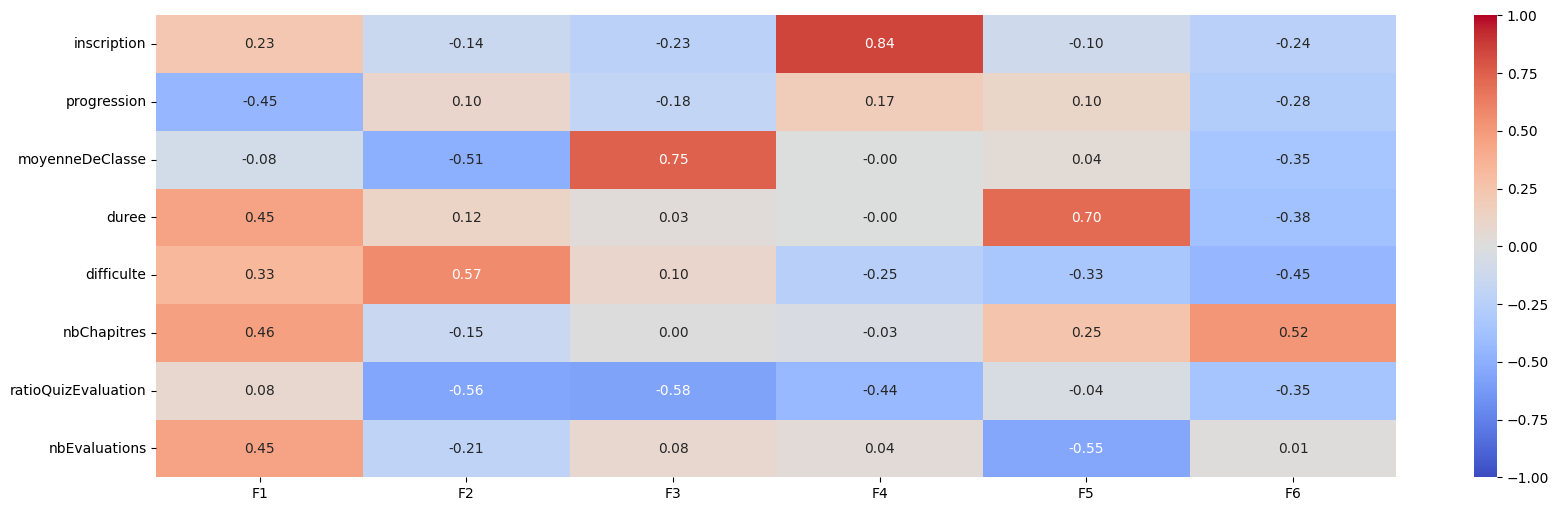

In [105]:
# Représentation visuelle
fig, ax = plt.subplots (figsize = (20,6))
sns.heatmap (pcs.T, vmin=-1, vmax = 1, annot = True, cmap = 'coolwarm', fmt = '0.2f')

Cette visualisation permet de mieux voir les variables les plus représentées sur chaque composante

In [32]:
pcs

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations
F1,0.232291,-0.453036,-0.084496,0.448654,0.331149,0.464390,0.081035,0.447756
F2,-0.138551,0.095709,-0.505901,0.119464,0.567023,-0.148200,-0.559942,-0.210767
F3,-0.232911,-0.181312,0.749591,0.025781,0.097971,0.001625,-0.577726,0.083419
F4,0.844563,0.173451,-0.003742,-0.003797,-0.251135,-0.031956,-0.437075,0.038423
F5,-0.101944,0.103747,0.042800,0.704342,-0.330498,0.254768,-0.039596,-0.552459
F6,-0.241783,-0.280837,-0.345714,-0.382050,-0.447063,0.522320,-0.352665,0.011602


## 3.5. Cercle de correlations

In [108]:
#Nous définissons nos axes x et y
x, y = 0, 1

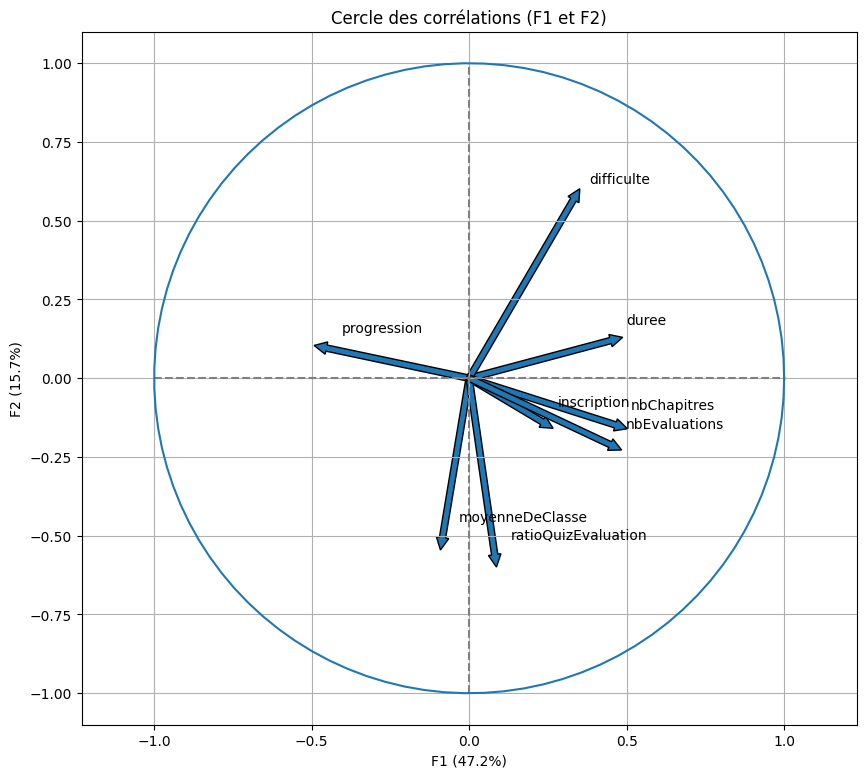

In [111]:
fig, ax = plt.subplots (figsize = (10,9))
for i in range (0, pca.components_.shape [1]) : 
    ax.arrow (0, 0,
              pca.components_ [x, i],
              pca.components_ [y,i],
              head_width = 0.04,
              head_length = 0.04,
              width = 0.02)
    plt.text (pca.components_[0,i] + 0.05,
              pca.components_[1,i] + 0.05,
              features [i])

#affichage des lignes horizontales et verticales
plt.plot ([-1, 1], [0, 0], color = 'grey', ls = '--')
plt.plot ([0, 0], [-1, 1], color = 'grey', ls = '--')

#nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel ('F{} ({}%)'.format(x+1, round (100 * pca.explained_variance_ratio_[x],1)))
plt.ylabel ('F{} ({}%)'.format(y+1, round (100 * pca.explained_variance_ratio_[y],1)))

plt.title ('Cercle des corrélations (F{} et F{})'.format (x+1, y+1))
plt.grid()

#Tracé du cercle
an = np.linspace (0,2 * np.pi, 100)
plt.plot (np.cos (an), np.sin (an))
plt.axis ('equal')
plt.show (block = False)

In [35]:
pca.components_ [0,1]

np.float64(-0.4530356815988338)

Creons une fonction pour tracer le cercle de correlation

In [120]:
def cercle_correlation (pca, x_y, features) :
    
    x,y = x_y
    
    '''
    #Récuperer les composantes à représenter
    x = int (input (f'Quelle composante voulez-vous représenter (entre 1 et {pca.components_.shape [0]})')) - 1
    print()
    y = int (input (f'Quelle composante voulez-vous représenter (entre 1 et {pca.components_.shape [0]})')) - 1
    
    '''
    
    #Taille de l'image
    fig, ax = plt.subplots (figsize = (10,6))

    for i in range (0, pca.components_.shape [1]) : 
        #Tracé des flèches
        ax.arrow (0, 0, 
                pca.components_ [x, i],
                pca.components_ [y, i],
                head_width = 0.05,
                head_length = 0.05,
                width = 0.02)
        
        #Affichage du texte pour chaque variable
        plt.text (pca.components_ [x, i]+0.03,
                pca.components_ [y, i]+0.03,
                features [i])
        

    plt.title (f'Cercle des correlations F({x+1}) et F({y+1})')

    # Affichage des lignes horizontales et verticales
    plt.plot ([-1,1], [0,0], ls = '--', color = 'grey')
    plt.plot ([0,0], [-1,1], ls = '--', color = 'grey')

    # Affichage noms des axes et pourcentage de variance expliquée
    plt.xlabel ('F{} ({}%)'.format (x+1, round (100 * pca.explained_variance_ratio_ [x], 2)))
    plt.ylabel ('F{} ({}%)'.format (y+1, round (100 * pca.explained_variance_ratio_[y], 2)))

    # Tracé du cercle
    cercle = np.linspace (0, 2*np.pi, 100)
    plt.plot (np.cos (cercle),np.sin (cercle))

    # Axes et display
    plt.axis('equal')
    plt.grid()
    plt.show(block = False)

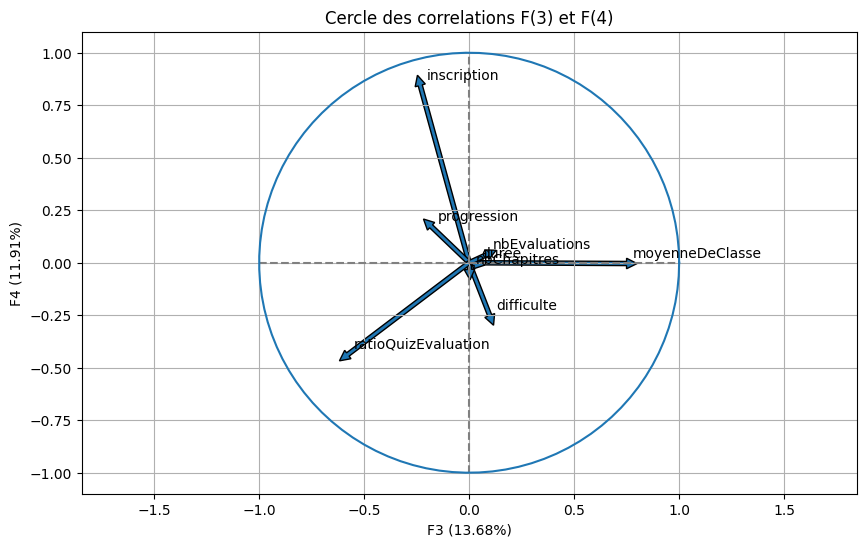

In [147]:
cercle_correlation (pca, (2,3), features)

<Axes: >

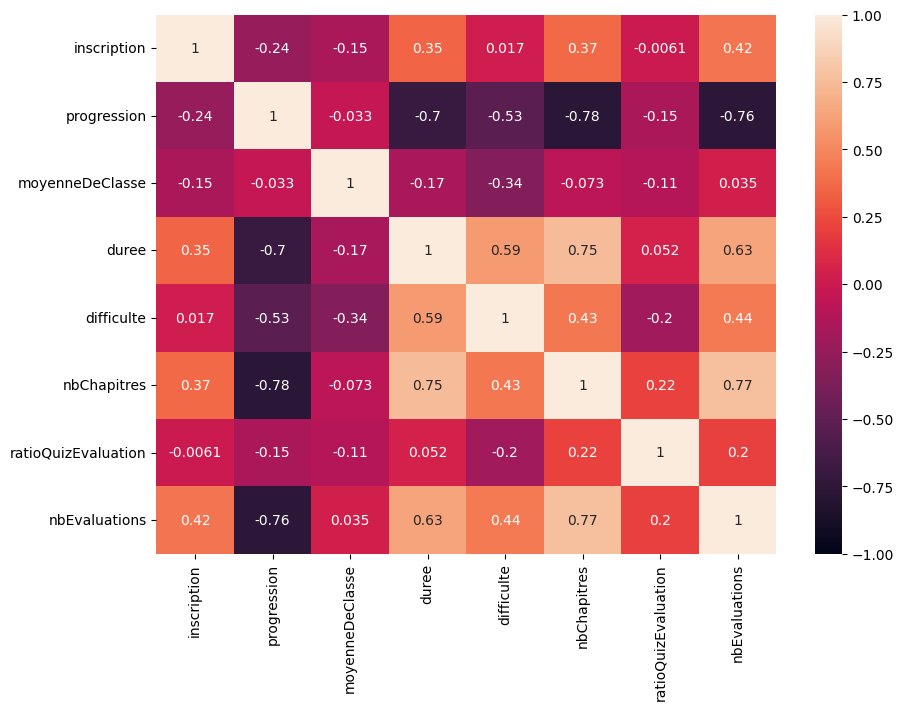

In [150]:
#Générons une matrice de correlation pour nous aider à interpréter nos résultats
plt.figure (figsize = (10,7))
sns.heatmap (data.corr(), vmin=-1, vmax=1, annot=True)

Interprétation : 

La composante 1 F1 est celle qui explique la longueur de chaque cours, les variables les plus descriptives de cette composante sont duree, nbChapitres, nbEvaluations et progression. un cours long,avec beaucoup de chapitres et d'évaluations est associé à une progression plus faible des apprenants. Cette analyse se confirme en observant la correlation entre les variables prises deux à deux.

La composante F2 capte mieux le niveau générale/performance pour chaque cours puisque les variables difficulté, moyenneDeClasse et ratioQuizEvaluation sont les mieux représentées sur cet axe. Et il en va que plus un cours est difficile, moins la performance est bonne.

La composante F3 est principalement structurée par moyenneDeClasse et ratioQuizEvaluation, avec un signe opposé entre les deux. Cet composante suggère qu'un cours dont l'évaluation repose davantage sur des quiz (ratio de quiz élevé) tend à afficher une moyenne plus faible, tandis qu'un cours avec une proportion plus importante d'activités (par opposition aux quiz) tend à afficher une moyenne plus élevée. Cette relation reste toutefois à interpréter avec prudence : la corrélation brute entre ces deux variables prises isolément est faible (-0,11), ce qui indique que la composante capte une combinaison plus large impliquant l'ensemble des variables plutôt qu'un lien direct et fort entre ces deux seules variables.

La composante F4 est très largement dominée par inscription (0.84), les autres variables (notamment ratioQuizEvaluation à -0.44 et difficulte à -0.25) n'ayant qu'une contribution secondaire. Cette composante reflète donc avant tout l'ancienneté d'inscription au cours. La contribution de ratioQuizEvaluation existe dans la combinaison linéaire, mais la corrélation brute entre inscription et ratioQuizEvaluation est quasi nulle (-0,0061), on ne peut donc pas considérer l'existence d'un lien direct fort entre les deux variables. La composante F4 est donc un effet secondaire de la projection multivariée plutôt que comme une relation interprétable en soi.

## 3.6. Projection des variables

In [36]:
X_proj = pca.transform (X_scaled)
print (X_proj)

[[ 0.22107277  1.06394473  0.3874128  -1.63322222 -0.61683984 -0.70983399]
 [ 0.88754323  0.03499815 -0.56814276 -1.42793746 -0.52608729  1.10258485]
 [-2.95501419  0.11477732 -0.3232466  -0.29987584  1.30771945 -0.40701673]
 [-1.69361161  1.07862307  3.17074995  0.40249607  0.05356553  0.12275527]
 [-1.86989322 -1.7847995  -0.87896007 -0.9500123  -0.08170767 -0.19571633]
 [ 1.28861015 -0.26687152  1.17861081 -0.19404767  0.22865319  0.53841576]
 [-3.00499944 -0.24355067 -0.44303432  0.28300115  0.28521331  0.18152462]
 [-0.99019557  1.44435679 -0.96165067  0.08485137 -0.23596961  0.38465086]
 [ 0.14098928  1.65156184 -1.01793738 -0.58577178 -0.59710931 -0.71865533]
 [ 1.17102884 -1.42660138  1.21222908 -0.73005617 -0.20254706  0.0532678 ]
 [-1.02544007  0.65020597  0.21865588  0.03602379 -0.44254028 -0.00532687]
 [ 1.71098075 -1.04902297  0.99979806 -0.60154486  0.7395521  -0.69991486]
 [-0.46712953 -1.81275477  0.07606219  0.15560172 -0.40956711  0.68019223]
 [ 1.18411502 -0.81075755

In [54]:
type (X_proj)

numpy.ndarray

### Test de cohérence

In [134]:
#Nous vérifions que le résultat est semblable à celui trouvé tout à l'heure avec la méthode np.linalg.svd
#Il faut se rappeler que 8 composantes sont représentées pour la méthode np.linalg.svd contre 6 pour la méthode sklearn

np.allclose (X_projected [:,:6], X_proj)

False

On voit que les deux méthodes ne donnent pas les mêmes résultats.
Regardons les matrices de plus près

In [139]:
X_projected [:5,:6]

array([[ 0.22107277,  1.06394473,  0.3874128 ,  1.63322222,  0.61683984,
        -0.70983399],
       [ 0.88754323,  0.03499815, -0.56814276,  1.42793746,  0.52608729,
         1.10258485],
       [-2.95501419,  0.11477732, -0.3232466 ,  0.29987584, -1.30771945,
        -0.40701673],
       [-1.69361161,  1.07862307,  3.17074995, -0.40249607, -0.05356553,
         0.12275527],
       [-1.86989322, -1.7847995 , -0.87896007,  0.9500123 ,  0.08170767,
        -0.19571633]])

In [140]:
X_proj [:5]

array([[ 0.22107277,  1.06394473,  0.3874128 , -1.63322222, -0.61683984,
        -0.70983399],
       [ 0.88754323,  0.03499815, -0.56814276, -1.42793746, -0.52608729,
         1.10258485],
       [-2.95501419,  0.11477732, -0.3232466 , -0.29987584,  1.30771945,
        -0.40701673],
       [-1.69361161,  1.07862307,  3.17074995,  0.40249607,  0.05356553,
         0.12275527],
       [-1.86989322, -1.7847995 , -0.87896007, -0.9500123 , -0.08170767,
        -0.19571633]])

On voit que les résultats sont différents à cause des signes des composantes F4 et F5. Corrigeons cela et comparons à nouveau

In [141]:
signs = np.sign (X_projected [0, :6] * X_proj [0,:]) #nous récupérons le signe pour chaque colonne
X_proj_sign = X_projected [: ,:6] * signs   #nous affectons les signes trouvés précédemment à un de nos résultats
np.allclose (X_proj_sign, X_proj)

True

Notre test de cohérence est bien réussi, les deux méthodes donnent les mêmes résultats

### Représentation graphique

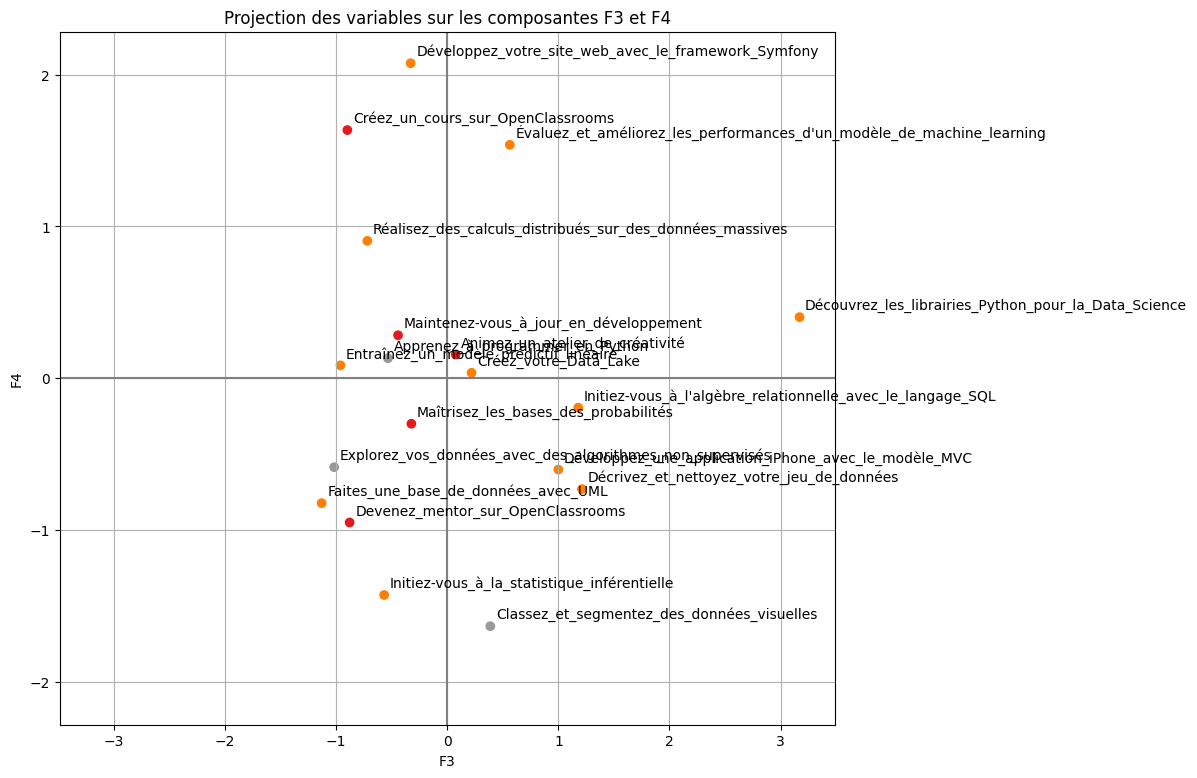

In [83]:
fig, ax = plt.subplots (1, 1, figsize = (10,9))

x, y = (2,3)

axe_x = X_proj [:, x]
axe_y = X_proj [:, y]


plt.scatter  (axe_x, axe_y, c= data ['difficulte'], cmap='Set1', marker = 'o')

#Valeurs max du graphe
x_max = np.abs (axe_x).max () * 1.1
y_max = np.abs (axe_y).max () * 1.1

#Bornes du graphe
ax.set_xlim (left = - x_max, right = x_max)
ax.set_ylim (bottom = - y_max, top = y_max )

#Tracé des axes centraux
plt.plot ([-x_max, x_max], [0,0], color = 'grey', alpha = 1)
plt.plot ([0,0], [-y_max, y_max], color = 'grey', alpha = 1)

#Affichage des noms des cours
for i in range (names.shape [0]) : 
    plt.text (axe_x [i] + 0.05, axe_y [i] + 0.05, names [i])


plt.title (f'Projection des variables sur les composantes F{x+1} et F{y+1}')
plt.xlabel (f'F{x+1}')
plt.ylabel (f'F{y+1}')
plt.grid ()
